# **Description**

**Introduce**
The Breast Cancer Classification using Clinical and Biopsy Data project focuses on leveraging machine learning models to classify breast tumors as benign or malignant based on clinical biomarkers and biopsy features. The project compares various machine learning algorithms, such as classical models (SVM, Random Forest, Logistic Regression) and deep learning models (MLP), to assess predictive accuracy. The analysis also emphasizes feature importance and interpretable AI methods, such as SHAP, to understand the most relevant factors influencing tumor classification

**Research Question**
1. Can machine learning models reliably classify breast tumors as benign or malignant based on clinical and biopsy data?

2. What clinical and biopsy features are most indicative of tumor malignancy, and how do feature interactions affect the model's robustness?

3. How do model complexity and interpretability (e.g., through SHAP or feature importance) impact the classification of breast cancer in clinical decision support?

**Dataset Details:**

**Name:** Breast Cancer Wisconsin Diagnostic Dataset

**Source:** UCI Machine Learning Repository - Breast Cancer Wisconsin Diagnostic Data Set

**Contributors:** Dr. William H. Wolberg at the University of Wisconsin Hospitals, Madison, USA

# **Importing Files**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np



**Loading Dataset and Converting the column Name into relevent names**

In [ ]:

# Load the dataset
df = pd.read_csv('wdbc.data', header=None)

# specifying column names
column_names = [
    'ID', 'Diagnosis',
    'Radius_mean', 'Texture_mean', 'Perimeter_mean', 'Area_mean', 'Smoothness_mean',
    'Compactness_mean', 'Concavity_mean', 'Concave_points_mean', 'Symmetry_mean',
    'Fractal_dimension_mean', 'Radius_se', 'Texture_se', 'Perimeter_se', 'Area_se',
    'Smoothness_se', 'Compactness_se', 'Concavity_se', 'Concave_points_se', 'Symmetry_se',
    'Fractal_dimension_se', 'Radius_worst', 'Texture_worst', 'Perimeter_worst',
    'Area_worst', 'Smoothness_worst', 'Compactness_worst', 'Concavity_worst',
    'Concave_points_worst', 'Symmetry_worst', 'Fractal_dimension_worst'
]


**Printing Column Names**

In [ ]:

# Assign the column names
df.columns = column_names

df.columns

Index(['ID', 'Diagnosis', 'Radius_mean', 'Texture_mean', 'Perimeter_mean',
       'Area_mean', 'Smoothness_mean', 'Compactness_mean', 'Concavity_mean',
       'Concave_points_mean', 'Symmetry_mean', 'Fractal_dimension_mean',
       'Radius_se', 'Texture_se', 'Perimeter_se', 'Area_se', 'Smoothness_se',
       'Compactness_se', 'Concavity_se', 'Concave_points_se', 'Symmetry_se',
       'Fractal_dimension_se', 'Radius_worst', 'Texture_worst',
       'Perimeter_worst', 'Area_worst', 'Smoothness_worst',
       'Compactness_worst', 'Concavity_worst', 'Concave_points_worst',
       'Symmetry_worst', 'Fractal_dimension_worst'],
      dtype='object')

**Printing First Few Columns**

In [ ]:
# Display first few rows to check
df.head()


,ID,Diagnosis,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,...,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Checking if there are any null values**

In [ ]:
# Check for missing values
df.isnull().sum()


,0
ID,0
Diagnosis,0
Radius_mean,0
Texture_mean,0
Perimeter_mean,0
Area_mean,0
Smoothness_mean,0
Compactness_mean,0
Concavity_mean,0
Concave_points_mean,0


**Displaying Shape of Dataset**

In [ ]:
df.shape

(569, 32)

# **Descriptive statistical Analysis**

In [ ]:
df.describe()

,ID,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,Symmetry_mean,...,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**Checking the numbers of values in Target Column**

In [ ]:
# Check the original counts for 'M' (Malignant) and 'B' (Benign)
df['Diagnosis'].value_counts()


,count
Diagnosis,
B,357
M,212


**Converting Malignant to 1 and Benine to 0**

In [ ]:
# Convert 'M' to 1 and 'B' to 0
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# Display the first few rows to confirm the conversion
df.head()

,ID,Diagnosis,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,...,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Distribution of Numerical Features**

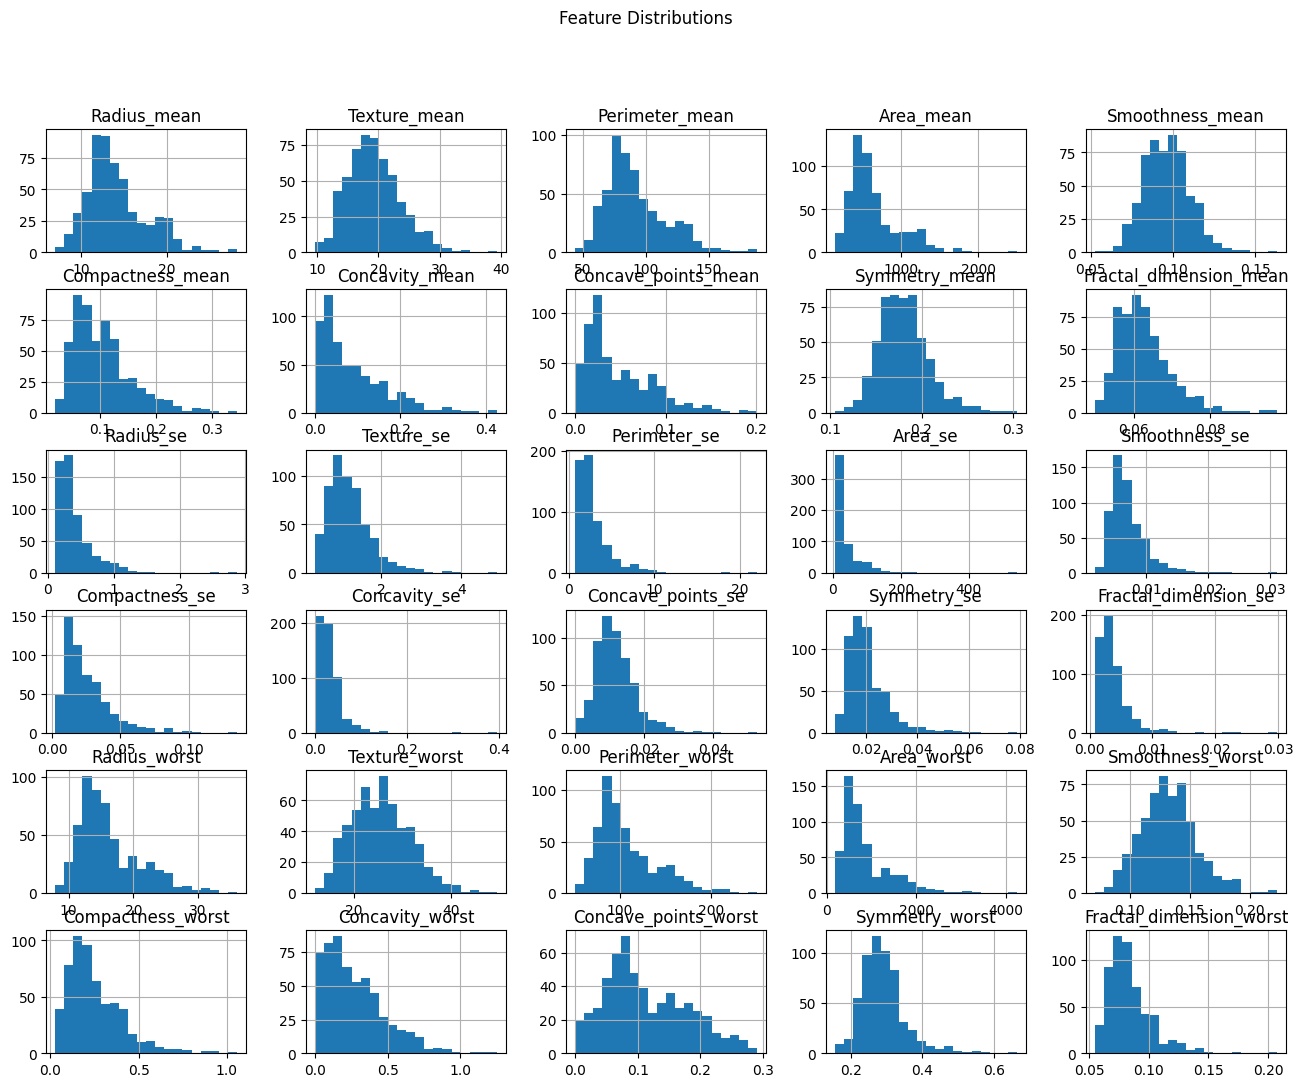

In [ ]:
# Histograms of numerical features
df.iloc[:, 2:].hist(bins=20, figsize=(16, 12))
plt.suptitle('Feature Distributions')
plt.show()


**Distribution of Target Variable**

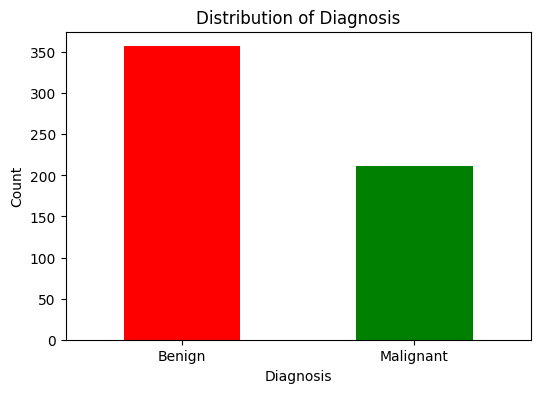

In [ ]:

# Distribution of diagnosis (Malignant vs Benign)
plt.figure(figsize=(6, 4))
df['Diagnosis'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribution of Diagnosis')
plt.xticks([0, 1], ['Benign', 'Malignant'], rotation=0)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


**Box Plot**

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


<Figure size 1200x800 with 0 Axes>

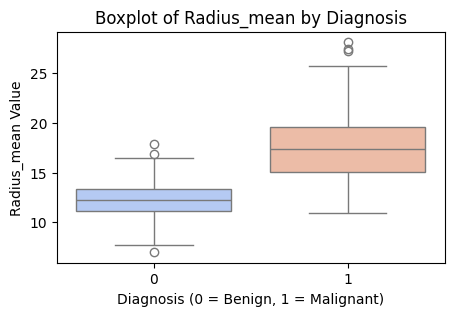

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


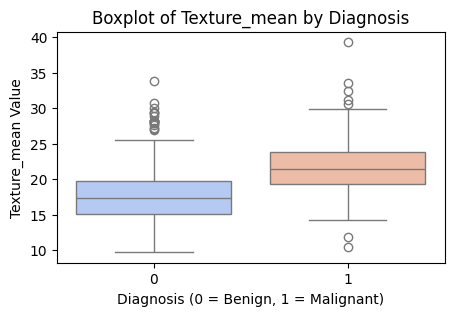

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


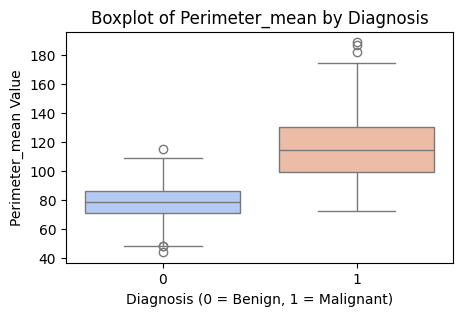

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


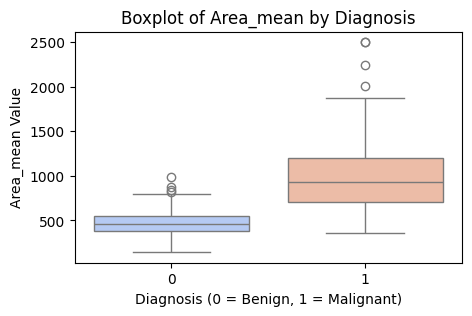

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


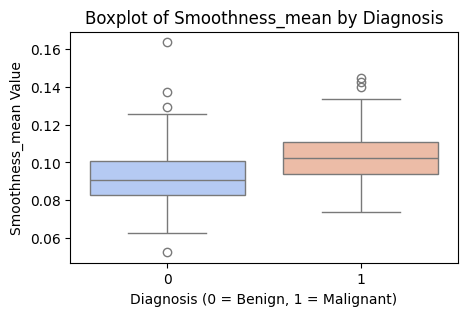

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


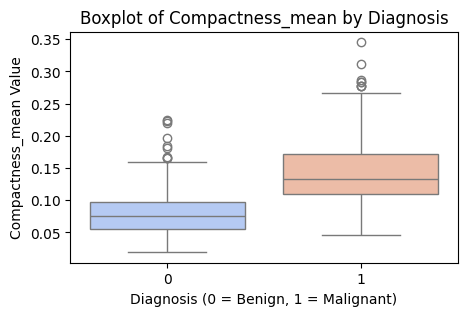

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


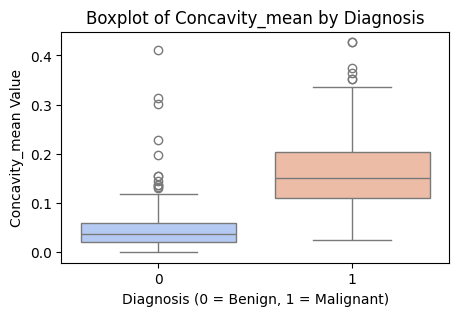

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


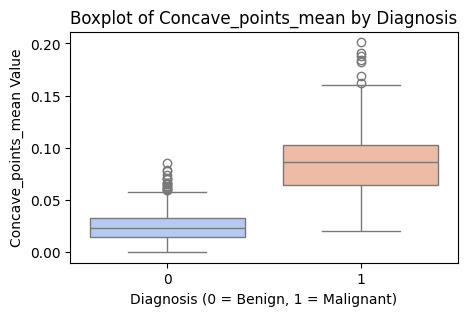

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


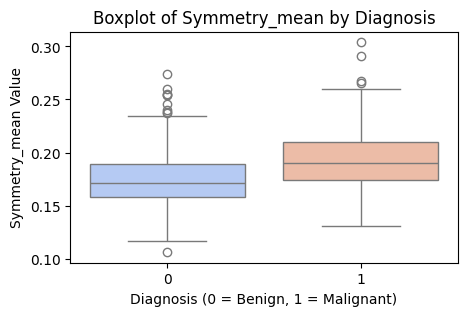

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


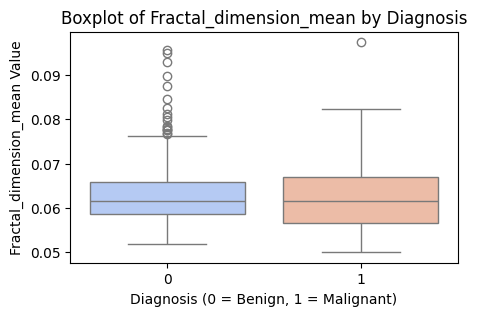

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


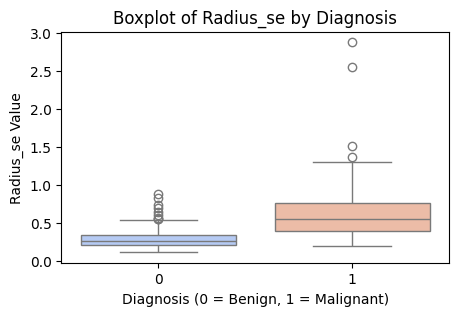

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


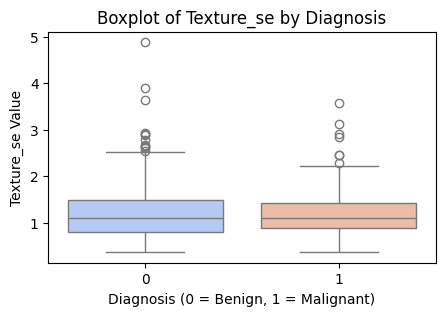

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


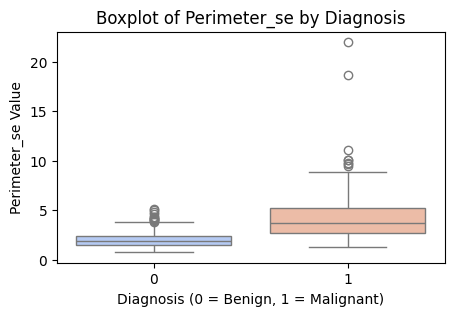

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


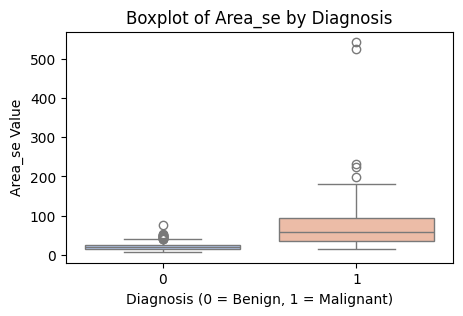

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


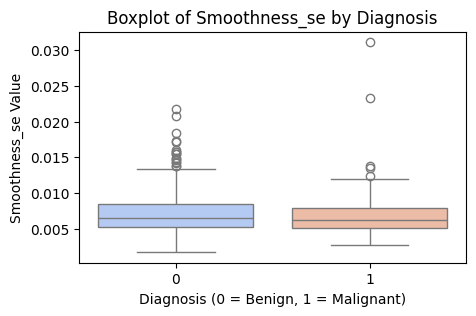

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


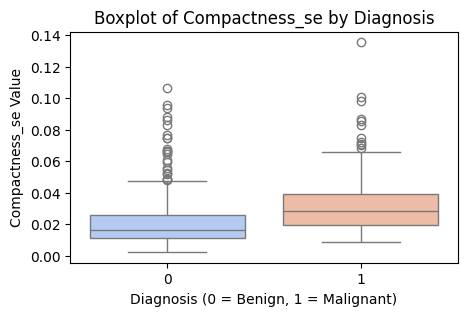

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


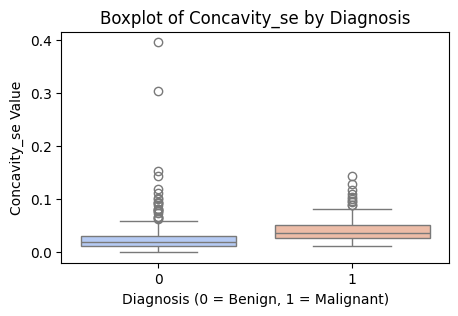

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


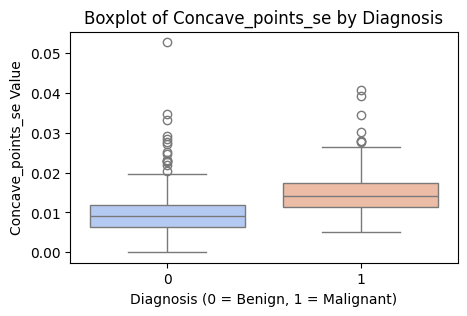

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


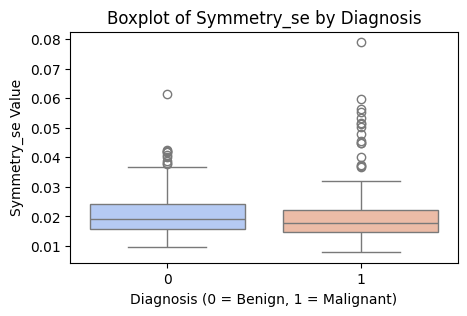

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


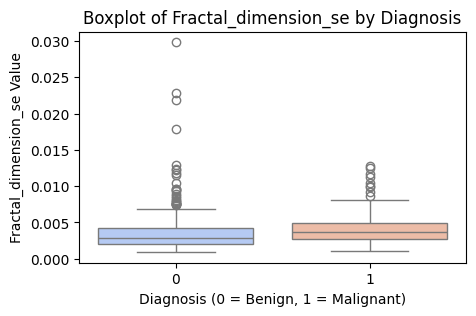

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


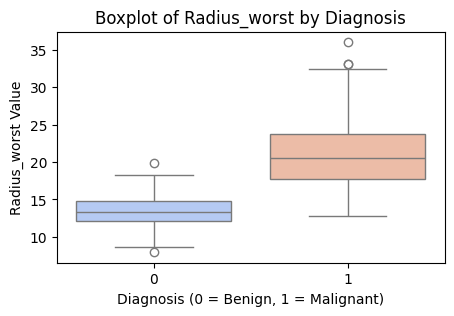

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


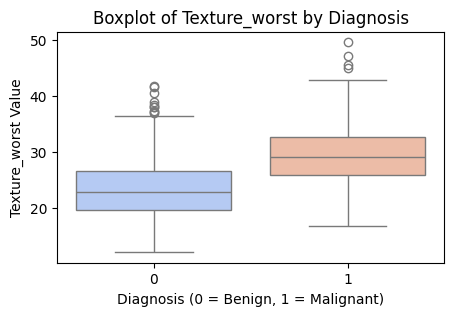

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


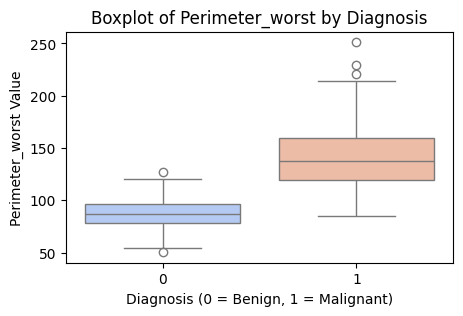

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


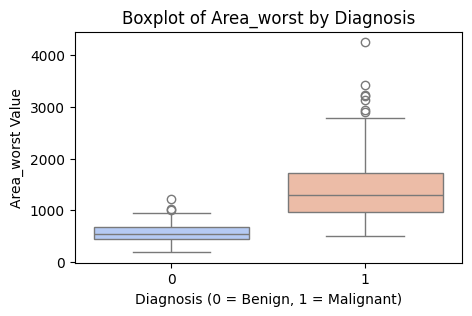

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


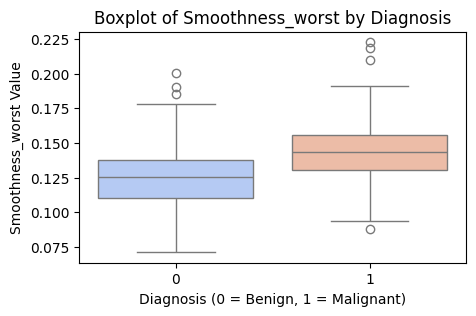

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


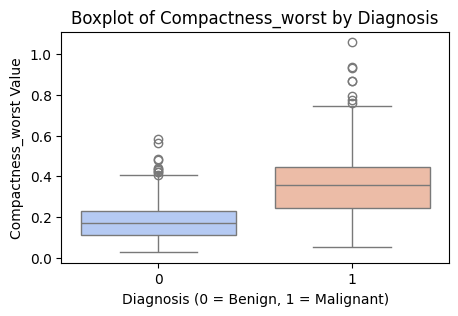

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


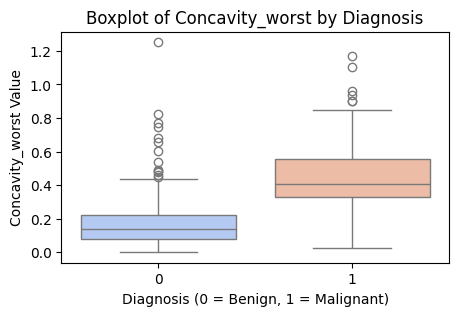

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


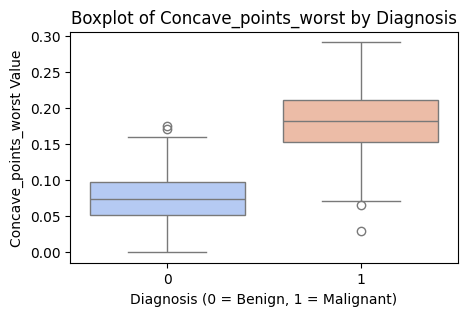

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


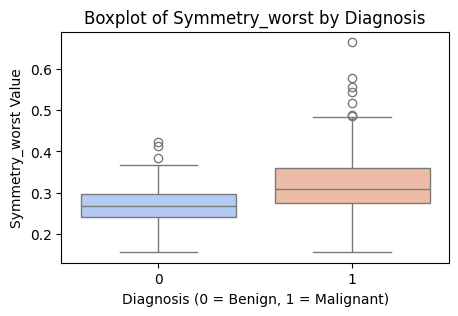

/tmp/ipython-input-935009325.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')


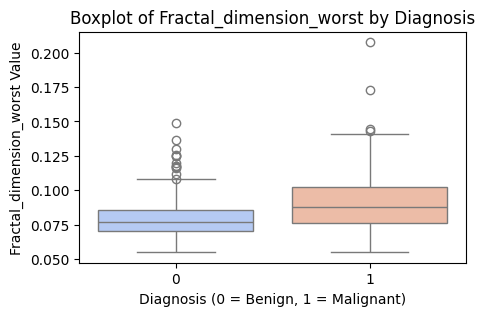

In [ ]:
# Melt the DataFrame to long-form data for boxplot visualization
df_melted = df.iloc[:, 2:].copy()
df_melted['Diagnosis'] = df['Diagnosis']

# Set up the figure for better readability
plt.figure(figsize=(12, 8))

# Create a boxplot for each feature by Diagnosis (Malignant vs Benign)
for feature in df_melted.columns[:-1]:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x='Diagnosis', y=feature, data=df_melted, palette='coolwarm')
    plt.title(f'Boxplot of {feature} by Diagnosis')
    plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
    plt.ylabel(f'{feature} Value')
    plt.show()
